Total parameter combinations: 162
Total iterations (parameter combinations × CV folds): 1620
Starting Grid Search with AdaBoost and Progress Bar...
                                                                                

on 1620: /home/pshw13/myenv/lib/python3.10/site-packages/numpy/ma/core.py:2881: RuntimeWarning: invalid value encountered in cast
           _data = np.array(data, dtype=dtype, copy=copy,


Grid Search Progress |▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉| 1620/1620 [100%]
Grid Search Completed.

Best Average AUC: 0.7790 ± 0.0228
Average Accuracy: 0.8908 ± 0.0099
Average Precision: 0.3423 ± 0.0934
Average F1 Score: 0.2664 ± 0.0791

Best Hyperparameters:
  ada__algorithm: SAMME
  ada__estimator__max_depth: 20
  ada__estimator__max_features: sqrt
  ada__estimator__min_samples_leaf: 2
  ada__estimator__min_samples_split: 25
  ada__learning_rate: 1e-05
  ada__n_estimators: 250
  sampler: ADASYN
  sampler__sampling_strategy: 0.2

Generating cross-validated predicted probabilities...
Optimizing threshold to maximize F1 score...

Calculating metrics at the optimal threshold across folds...
  Fold 1: F1=0.3115, Accuracy=0.7286, Precision=0.2032
  Fold 2: F1=0.3333, Accuracy=0.7605, Precision=0.2229
  Fold 3: F1=0.3679, Accuracy=0.7832, Precision=0.2500
  Fold 4: F1=0.3246, Accuracy=0.7508, Precision=0.2151
  Fold 5: F1=0.2944, Accuracy=0.7362, Precision=0.1943
  Fold 6: F1=0.2731, A

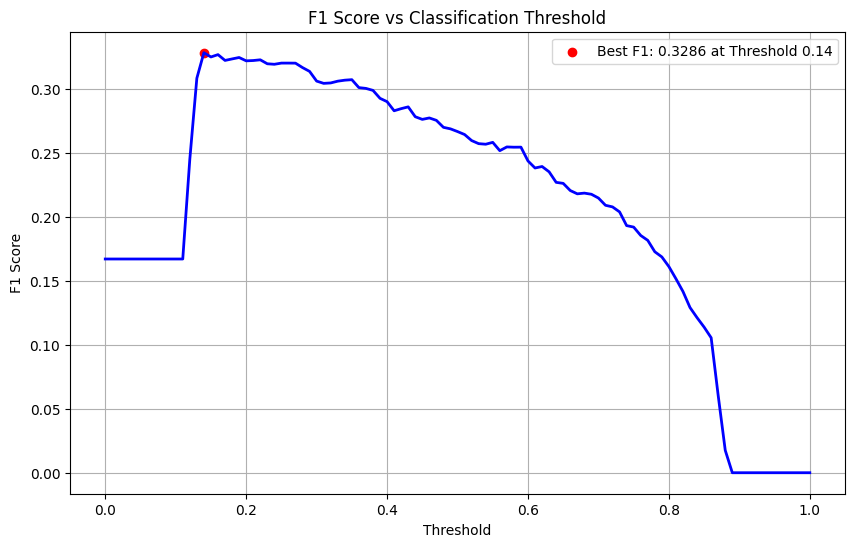

In [1]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning, ConvergenceWarning

# Suppress UndefinedMetricWarning and FutureWarning globally
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import numpy as np
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, f1_score, make_scorer
from imblearn.pipeline import Pipeline  # Use imblearn's Pipeline
import matplotlib.pyplot as plt
from math import prod

# Import oversampling techniques
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

# Import libraries for progress bar
from alive_progress import alive_bar
from contextlib import contextmanager
from joblib.parallel import BatchCompletionCallBack
import threading
import logging
import os

# Set environment variable to suppress Python warnings
os.environ['PYTHONWARNINGS'] = "ignore"

# Suppress logging warnings by setting the logging level to ERROR
logging.getLogger().setLevel(logging.ERROR)

# Import alive-progress for the progress bar
from alive_progress import alive_bar
from contextlib import contextmanager
from joblib.parallel import BatchCompletionCallBack
import threading

# Load the dataset
# Replace the file path with your actual path
data = pd.read_excel("class123_dataset.xlsx")

# Extract the predictors and outcome
X = data.drop('RRI', axis=1)
Y = data['RRI']

# Define the feature indexes to be used as predictors
# Note: Pandas uses 0-based indexing
feature_indexes = [28, 234, 36, 215, 189, 37, 77, 26, 250, 188, 236, 181, 70, 55, 48, 67, 202, 244, 78, 65, 52, 237, 211, 57, 185, 229, 231, 219, 62, 220, 51, 200, 30, 242, 233, 198, 34, 25, 212, 205, 252, 32, 29, 248, 253, 75, 66, 247, 56, 58, 12, 221, 41, 197, 7, 63, 217, 1, 251, 199, 114, 49, 24, 50, 101, 80, 186, 232, 207, 130, 79, 115, 43, 243, 190, 137, 136, 108, 46, 214, 17, 10, 110, 88, 125, 182, 33, 203, 225, 68, 213, 227, 126, 93, 81, 14, 13, 104, 92, 42, 201, 129, 177, 122, 134, 133, 60, 19, 31, 9, 135, 98, 8, 45, 3, 47, 4, 6, 226, 116, 106, 90, 15, 105, 138, 18, 89, 84, 100, 44, 228, 131, 38, 112, 103, 96, 16, 127, 206, 117, 11, 102, 176, 128, 97, 0, 132, 5, 256, 61, 235, 87, 91, 193, 39, 111, 64, 180, 99]

# Select the specified features using .iloc
X_selected = X.iloc[:, feature_indexes]

# Initialize the base estimator for AdaBoost
estimator = DecisionTreeClassifier(random_state=42)

# Create a Pipeline with oversampling and AdaBoost
pipeline = Pipeline([
    ('sampler', RandomOverSampler()),  # Initialize with a default oversampler
    ('ada', AdaBoostClassifier(random_state=42, estimator=estimator))  # Use 'estimator' instead of 'base_estimator'
])

# Define custom scorers with zero_division=0 to prevent warnings
precision_scorer = make_scorer(precision_score, zero_division=0)
f1_scorer = make_scorer(f1_score, zero_division=0)

# Define the scoring metrics
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'precision': precision_scorer,  # Use custom scorer
    'f1': f1_scorer  # Use custom scorer
}

# Define the Stratified 10-Fold Cross-Validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define the parameter grid for hyperparameter tuning
param_grid = [
    # Case with oversamplers
    {
        'sampler': [ADASYN()],
        'sampler__sampling_strategy': [0.2, 0.3, 0.4],
        'ada__n_estimators': [250],
        'ada__learning_rate': [0.000001, 0.00001, 0.0001],
        'ada__algorithm': ['SAMME'],
        'ada__estimator__max_depth': [20, 25],
        'ada__estimator__min_samples_split': [15, 20, 25],
        'ada__estimator__min_samples_leaf': [2],
        'ada__estimator__max_features': ['sqrt', 'log2', None],
    }
]

# Calculate the total number of parameter combinations
n_param_combinations = sum([prod([len(v) for v in param_dict.values()]) for param_dict in param_grid])

# Calculate the total number of iterations (parameter combinations × CV folds)
total_iterations = n_param_combinations * cv.get_n_splits(X_selected, Y)

print(f"Total parameter combinations: {n_param_combinations}")
print(f"Total iterations (parameter combinations × CV folds): {total_iterations}")

# Define a context manager to integrate alive-progress with joblib's Parallel processing
@contextmanager
def alive_joblib_bar(total):
    """
    Context manager to integrate alive-progress with joblib's Parallel processing.

    Parameters:
    - total: int, the total number of tasks to be processed.
    """
    with alive_bar(total, title='Grid Search Progress', bar='blocks', force_tty=True) as bar:
        # Store the original BatchCompletionCallBack.__call__ method
        original_callback = BatchCompletionCallBack.__call__
        lock = threading.Lock()

        def on_complete(self, *args, **kwargs):
            with lock:
                bar()
            return original_callback(self, *args, **kwargs)

        # Patch the BatchCompletionCallBack.__call__ method
        BatchCompletionCallBack.__call__ = on_complete
        try:
            yield
        finally:
            # Restore the original method to avoid side effects
            BatchCompletionCallBack.__call__ = original_callback

# Initialize Grid Search with cross-validation
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit='roc_auc',  # Use 'roc_auc' to select the best model
    cv=cv,
    n_jobs=-1,  # Use all available cores
    verbose=0,  # Disable sklearn's verbose
    return_train_score=False
)

# Start the Grid Search with alive-progress
print("Starting Grid Search with AdaBoost and Progress Bar...")

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
    with alive_joblib_bar(total_iterations):
        grid_search.fit(X_selected, Y)

print("Grid Search Completed.")

# Retrieve the best average AUC and its standard deviation
best_auc = grid_search.best_score_
# Retrieve the standard deviation from cv_results_
# Identify the index of the best parameter set
best_index = grid_search.best_index_
best_auc_std = grid_search.cv_results_['std_test_roc_auc'][best_index]

# Retrieve the best hyperparameters
best_params = grid_search.best_params_

# Retrieve the other metrics for the best parameter set
best_accuracy = grid_search.cv_results_['mean_test_accuracy'][best_index]
best_accuracy_std = grid_search.cv_results_['std_test_accuracy'][best_index]

best_precision = grid_search.cv_results_['mean_test_precision'][best_index]
best_precision_std = grid_search.cv_results_['std_test_precision'][best_index]

best_f1 = grid_search.cv_results_['mean_test_f1'][best_index]
best_f1_std = grid_search.cv_results_['std_test_f1'][best_index]

# Output the results
print(f"\nBest Average AUC: {best_auc:.4f} ± {best_auc_std:.4f}")
print(f"Average Accuracy: {best_accuracy:.4f} ± {best_accuracy_std:.4f}")
print(f"Average Precision: {best_precision:.4f} ± {best_precision_std:.4f}")
print(f"Average F1 Score: {best_f1:.4f} ± {best_f1_std:.4f}")
print("\nBest Hyperparameters:")
for param, value in best_params.items():
    if isinstance(value, (SMOTE, ADASYN, RandomOverSampler)):
        print(f"  {param}: {value.__class__.__name__}")
    else:
        print(f"  {param}: {value}")

# Retrieve the best estimator from Grid Search
best_estimator = grid_search.best_estimator_

# Use cross_val_predict to get cross-validated predicted probabilities
# AdaBoost inherently supports predict_proba
print("\nGenerating cross-validated predicted probabilities...")
y_pred_proba = cross_val_predict(best_estimator, X_selected, Y, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]

# Define a range of threshold values to evaluate
thresholds = np.linspace(0.0, 1.0, 101)

# Initialize variables to store the best metrics and threshold
best_threshold = 0.5
best_f1_score = 0.0
best_accuracy = 0.0
best_precision = 0.0

print("Optimizing threshold to maximize F1 score...")

for threshold in thresholds:
    # Convert predicted probabilities to binary predictions based on the threshold
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    # Calculate F1 score
    current_f1 = f1_score(Y, y_pred, zero_division=0)
    
    # Update the best metrics and threshold if current F1 is better
    if current_f1 > best_f1_score:
        best_f1_score = current_f1
        best_threshold = threshold
        best_accuracy = accuracy_score(Y, y_pred)
        best_precision = precision_score(Y, y_pred, zero_division=0)

# Calculate standard deviations using cross-validation
# To compute standard deviations, we'll perform cross-validation predictions and calculate metrics at the best threshold

# Initialize lists to store per-fold metrics
f1_scores = []
accuracies = []
precisions = []

print("\nCalculating metrics at the optimal threshold across folds...")

for fold, (train_idx, test_idx) in enumerate(cv.split(X_selected, Y), 1):
    # Split data
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = Y.iloc[train_idx], Y.iloc[test_idx]
    
    # Fit the model on the training data
    best_estimator.fit(X_train, y_train)
    
    # Predict probabilities on the test data
    y_proba_fold = best_estimator.predict_proba(X_test)[:, 1]
    
    # Apply the optimal threshold
    y_pred_fold = (y_proba_fold >= best_threshold).astype(int)
    
    # Calculate metrics
    fold_f1 = f1_score(y_test, y_pred_fold, zero_division=0)
    fold_accuracy = accuracy_score(y_test, y_pred_fold)
    fold_precision = precision_score(y_test, y_pred_fold, zero_division=0)
    
    # Append to lists
    f1_scores.append(fold_f1)
    accuracies.append(fold_accuracy)
    precisions.append(fold_precision)
    
    print(f"  Fold {fold}: F1={fold_f1:.4f}, Accuracy={fold_accuracy:.4f}, Precision={fold_precision:.4f}")

# Calculate mean and standard deviation for the metrics
mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores)

mean_accuracy = np.mean(accuracies)
std_accuracy = np.std(accuracies)

mean_precision = np.mean(precisions)
std_precision = np.std(precisions)

# Output the optimized threshold and corresponding metrics
print(f"\n=== Optimized Threshold ===")
print(f"Threshold for Maximum F1 Score: {best_threshold:.2f}")

print(f"\n=== Metrics at Optimal Threshold ===")
print(f"F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")
print(f"Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}")
print(f"Precision: {mean_precision:.4f} ± {std_precision:.4f}")

# Plot F1 Score vs Threshold
f1_scores_plot = []
for threshold in thresholds:
    y_pred = (y_pred_proba >= threshold).astype(int)
    f1 = f1_score(Y, y_pred, zero_division=0)
    f1_scores_plot.append(f1)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores_plot, color='blue', lw=2)
plt.scatter(best_threshold, best_f1_score, color='red', 
            label=f'Best F1: {best_f1_score:.4f} at Threshold {best_threshold:.2f}')
plt.title('F1 Score vs Classification Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)
plt.show()